# Capstone: Define and Solve an ML Problem

In [1]:
import pandas as pd
import numpy as np
import os 
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import tensorflow.keras as keras
from sklearn.preprocessing import StandardScaler
import time

**Note**: As you work through the notebook, you can import additional packages as needed.

## Overview


In this capstone assignment, you will follow the machine learning life cycle and implement one of the supervised learning models you have learned so far in this course, along with a neural network, to solve a predictive problem.

This capstone spans two lab sessions.

- **Unit 5 Lab:** You will define a machine learning problem, explore and prepare your data, and train, test, evaluate and improve a traditional machine learning model (Parts 1–5).
- **Unit 6 Lab:** After completing Unit 6 on neural networks, you will apply a neural network to the same problem and compare the two approaches (Parts 6–7).

There is a checkpoint at the end of Part 5 that marks where to stop during the Unit 5 lab.

You will complete the following:

1. Choose your Data Set and Build Your DataFrame
2. Define Your ML Problem
3. Understand Your Data
4. Prepare Your Data
5. Train, Test, Evaluate and Improve a Traditional Machine Learning Model *(Unit 5 lab)*
6. Train, Test, Evaluate and Improve Neural Network *(Unit 6 lab)*
7. Compare Your Models and Reflect *(Unit 6 lab)*

**This is an individual assignment.** You are welcome to discuss ideas with your peers, but the code and written responses you submit must be your own.

**Note:** This capstone is intentionally less scaffolded than your weekly labs; that is by design. You are expected to make your own implementation choices, add code cells as needed, and document your reasoning throughout.

## Part 1: Choose Your Data Set and Build Your DataFrame


You will choose one of two data sets to work with for this capstone. In both cases, you will be solving a supervised learning binary classification problem by predicting one of two possible class labels. Both data sets have been used earlier in the course, so you are already familiar with their structure. 

**Option A: Census Income Data** (`censusData.csv`)
This data set contains demographic and employment information from the 1994 U.S. Census. You will use it to predict whether an individual's annual income exceeds $50,000. Your label column is `income_binary`, which contains two values: `<=50K` and `>50K`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Option B: Airbnb NYC Listings Data** (`airbnbListingsData.csv`)
This data set contains information about Airbnb listings in New York City. You will use it to predict whether a listing is high-priced. The data set includes a new `price_category` column that classifies each listing as either "high price" or "low price" based on whether the listing’s price falls above or below the 75th percentile of all listing prices. Listings at or above the 75th percentile are labeled as `high`, while the remaining listings are labeled as `low`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Note:**  These versions of the data sets differ slightly from the versions you have worked with in this program. For example, they may not include some of the preprocessing necessary for specific models. 

#### Load a Data Set and Save it as a Pandas DataFrame

The code cell below contains filenames (path + filename) for the two data sets available to you.

<b>Task:</b> In the code cell below, load your chosen data set using `pd.read_csv()` and save it to a DataFrame named `df`. Then call `df.head()` to inspect the first few row of the data set.

In [2]:
# File paths for both data sets
census_filename = os.path.join(os.getcwd(), "data_capstone", "censusData.csv")
airbnb_filename = os.path.join(os.getcwd(), "data_capstone", "airbnbListingsData.csv")

# Load your chosen dataset and save it to df
df = pd.read_csv(census_filename, header=0)

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex_selfID,capital-gain,capital-loss,hours-per-week,native-country,income_binary
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Non-Female,2174,0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Non-Female,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Non-Female,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Non-Female,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


## Part 2: Define Your ML Problem

The first step of the machine learning life cycle involves defining your business problem. In the markdown cell below, you will clearly define what you are trying to predict and why it matters. 

<b>Task</b>: In the markdown cell below, answer all of the following questions:

1. Which data set did you choose?
2. What is your label? What are you predicting?
3. What features do you plan to use? (This list may change after you explore your data.)
5. Why does this problem matter? Using the business brief you read in the lab overview page, explain how the organization described there could use a model that predicts this label to create value or inform decisions for their client.

1. I chose the Census Income Data problem


2. The label for this problem is the income_binary which tell us if our income is less than or euqal to, 50k or greater than 50k. This is what we're attempting to predict, based on a set of features can we predict if the individuals income is greater than or less than 50k. 


3. Currently the features I plan to use(Outside of the needed label), are relationship, age, workclass, education, marital-status, hours-per-week, native-country. At a first glance these are labels that could all potentially affect income.
 

4. This problem matters because EquiLend currently reviews every application by hand, which takes a lot of time and can lead cause inconsistent decisions. A machine learning model would help EquiLend identify whether an applicant is likely to earn above or below 50,000, allowing them to review applications more efficiently. This could speed up the eligibility process allowing for loans to be processed faster and help the organization serve more people while still allowing staff to review uncertain cases.

## Part 3: Understand Your Data

Now that you have defined your problem, perform exploratory data analysis (EDA) with that problem in mind. Consider the following as you inspect your data:

1. What data preparation techniques would you like to use? These data preparation techniques may include:

    * handling missing values
    * finding and replacing outliers
    * performing feature engineering techniques such as one-hot encoding on categorical features
    * selecting appropriate features and removing irrelevant features
    * addressing class imbalance


2. What machine learning model would you like to use that is suitable for your predictive problem and data?
   * You may use one of the following models that you have worked with so far:
        - K-Nearest Neighbors (KNN)
        - Decision Tree
        - Logistic Regression
   * Are there other data preparation techniques that you will need to apply to build a balanced modeling data set for your problem and model? For example, will you need to scale your data?
 

3. How will you evaluate and improve the model's performance?
    * Are there specific evaluation metrics or methods that are appropriate for your problem, dataset, or selected model?
    
<b>Task</b>: In the code cells below, use the techniques you have learned in this course to inspect and analyze your data.

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

### Class Imbalance

Examine the distribution of your label column to determine whether class imbalance is present. Use at least one visualization to show the class distribution. In the **EDA Summary** below, you will discuss how you plan to address any observed imbalance during data preparation.

In [3]:
y = df['income_binary']
X = df.drop(columns = 'income_binary')

print(f" Shape of features {X.shape}")


 Shape of features (32561, 14)


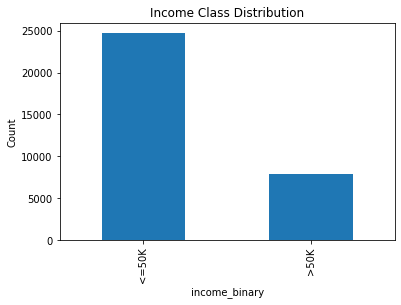

In [4]:
y.value_counts().plot(kind='bar')
plt.title("Income Class Distribution")
plt.xlabel("income_binary")
plt.ylabel("Count")
plt.show()

### Inspect and Analyze Your Data

Explore your features. Use summary statistics and visualizations to understand how your features are distributed and how they relate to the label. Identify issues such as missing values, outliers, or a feature that is irrelevant or redundant.

Think of the different techniques you have used to inspect and analyze your data in this course. These include using Pandas to apply data filters, using the Pandas `describe()` method to get insight into key statistics for each column, using the Pandas `dtypes` property to inspect the data type of each column, and using Matplotlib and Seaborn to detect outliers and visualize relationships between features and labels. 

Use at least one plot that visualizes a relationship between features and the label.

In [5]:
print(f" Shape of features {X.shape}")
print(f" DF Info {df.describe()}")

print(f" DF Missing Values: {df.isnull().sum()}")

print(f" DF all types: {df.dtypes}")

 Shape of features (32561, 14)
 DF Info                 age        fnlwgt  education-num  capital-gain  capital-loss  \
count  32399.000000  3.256100e+04   32561.000000  32561.000000  32561.000000   
mean      38.589216  1.897784e+05      10.080679    615.907773     87.303830   
std       13.647862  1.055500e+05       2.572720   2420.191974    402.960219   
min       17.000000  1.228500e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.178270e+05       9.000000      0.000000      0.000000   
50%       37.000000  1.783560e+05      10.000000      0.000000      0.000000   
75%       48.000000  2.370510e+05      12.000000      0.000000      0.000000   
max       90.000000  1.484705e+06      16.000000  14084.000000   4356.000000   

       hours-per-week  
count    32236.000000  
mean        40.450428  
std         12.353748  
min          1.000000  
25%         40.000000  
50%         40.000000  
75%         45.000000  
max         99.000000  
 DF Missing Values: age

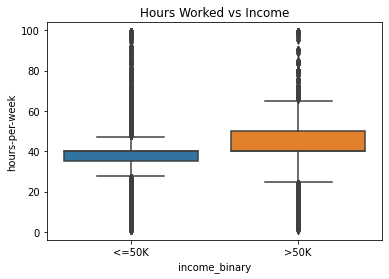

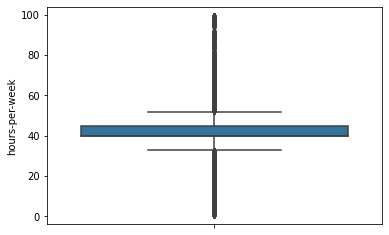

In [6]:
sns.boxplot(x='income_binary', y='hours-per-week', data=df)
plt.title("Hours Worked vs Income")
plt.show()

sns.boxplot(y=df['hours-per-week'])
plt.show()

### EDA Summary

<b>Task</b>: In the markdown cell below, summarize the key findings from your data exploration. Describe any patterns, anomalies, or data quality issues you identified and explain how those findings may influence your data preparation decisions. For example, your exploration may affect how you handle missing values, address class imbalance, or determine which features to keep or remove.

Features and Data Prep: I see that a good amount of features we would want to consider in our model are objects(workclass, education, occupation, and marital-status), so we would need to one hot encode and standardize how we factor these catergorical features in. But there are features like age and hours per week that are ready to be used and factor into income_binary according to plots. There aren't many features so we should have an efficent model after cleaning data. I also found missing values in age, workclass, occupation, hours-per-week, and native-country, so these will need to be handled during data preparation.

Class imbalance and Plots: The label is somewhat imbalanced, with about 25,000 individuals earning 50,000 or less and about 7,500 earning more than $50,000. Based on the plots, features like age and hours-per-week appear to have a relationship with income, so they are likely to be useful predictors.

### Ethical Considerations:

Machine learning models can cause harm when they reflect or amplify biases in the data they are trained on. 

<b>Task</b>: In the markdown cell below, answer both of the following questions:

1. What biases or ethical concerns might be present in your dataset? Think about who collected the data, how it was collected, and which groups of people appear in it. Are there features in the dataset that could serve as proxies for protected characteristics like race, gender, or socioeconomic status?
2. Who could be harmed by a model that makes incorrect predictions on this data, and how? Be specific about which groups are most at risk and what the real-world consequences of errors might look like.

1. In our current data set there are features like Race, Sex_selfID, Native_Country, Eduction that if handled improperly could cause a biased model. If the data set we end up working with doesn't cover a broad enough scope and overfits to a small training sample in a specfic location, this could lead to a model being biased towards groups and denying them loans at a disporpotionate rate(even if they would otherwise qualify). That is why it is important to evaulate feature weights and potentially elimnate features that can lead to negative/biased results.


2. When a model makes incorrect predictions due to bias, the groups most at risk are the ones who are already underrepresented in the data, such as certain racial groups, women, or immigrants. If the model incorrectly predicts that they earn more or less than they actually do, they could be unfairly denied loans or financial assistance that they would otherwise qualify for. Harming the companies goal while reducing access to important financial resources.

## Part 4: Prepare Your Data

<b>Task</b>: In the code cell below, prepare your data for modeling. The specific steps you take will depend on what you found during your EDA and which model you plan to use. 

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [7]:
# Dropping Features that hold no relevance to prediction
""" 
1. Describes a group and not an indivdiual example
2. # Already have eduction-num which has a scale for levels of eudcation, 3/4/5. Can cause model bias want to look at data without these considerations
"""

features_drop = [
    'fnlwgt',
    'education',
    'race',
    'sex_selfID',
    'native-country'
]

df = df.drop(columns=features_drop, errors='ignore')


In [8]:
#Fill missing values [workclass, age, occupation, hours-per-week]
# Fill with median
df['age'] = df['age'].fillna(df['age'].median())
df['hours-per-week'] = df['hours-per-week'].fillna(df['hours-per-week'].median())

# Fill with most frequent value-mode
df['workclass'] = df['workclass'].fillna(df['workclass'].mode()[0])
df['occupation'] = df['occupation'].fillna(df['occupation'].mode()[0])

In [9]:
#One hot Encode
from sklearn.preprocessing import OneHotEncoder
print(df.dtypes) #[workclass, marital-status, occupation,  relationship] Objects

#categorical_cols = ['workclass', 'marital-status','occupation','relationship']

#X = df.drop(columns='income_binary')
#y = df['income_binary']

#encoder = OneHotEncoder(sparse=False, handle_unknown='ignore')
#encoded = encoder.fit_transform(X[categorical_cols])

#encoded_df = pd.DataFrame(
   # encoded,
    #columns=encoder.get_feature_names(categorical_cols),
    #index=X.index
#)

#X = X.drop(columns=categorical_cols)

#X = pd.concat([X, encoded_df], axis=1)
#df = pd.concat([X, y], axis=1)
print(X)
df.head()


age               float64
workclass          object
education-num       int64
marital-status     object
occupation         object
relationship       object
capital-gain        int64
capital-loss        int64
hours-per-week    float64
income_binary      object
dtype: object
        age         workclass  fnlwgt   education  education-num  \
0      39.0         State-gov   77516   Bachelors             13   
1      50.0  Self-emp-not-inc   83311   Bachelors             13   
2      38.0           Private  215646     HS-grad              9   
3      53.0           Private  234721        11th              7   
4      28.0           Private  338409   Bachelors             13   
...     ...               ...     ...         ...            ...   
32556  27.0           Private  257302  Assoc-acdm             12   
32557  40.0           Private  154374     HS-grad              9   
32558  58.0           Private  151910     HS-grad              9   
32559  22.0           Private  201490     HS-g

,age,workclass,education-num,marital-status,occupation,relationship,capital-gain,capital-loss,hours-per-week,income_binary
0,39.0,State-gov,13,Never-married,Adm-clerical,Not-in-family,2174,0,40.0,<=50K
1,50.0,Self-emp-not-inc,13,Married-civ-spouse,Exec-managerial,Husband,0,0,13.0,<=50K
2,38.0,Private,9,Divorced,Handlers-cleaners,Not-in-family,0,0,40.0,<=50K
3,53.0,Private,7,Married-civ-spouse,Handlers-cleaners,Husband,0,0,40.0,<=50K
4,28.0,Private,13,Married-civ-spouse,Prof-specialty,Wife,0,0,40.0,<=50K


In [10]:
#Trasnfrom Label for model
df["income_binary"] = df["income_binary"].map({
    "<=50K": 0,
    ">50K": 1
})

### Data Preparation Summary:

<b>Task</b>: In the markdown cell below, document the data preparation steps you took. For each decision, explain why you made it. For example, why did you handle missing values the way you did? Why did you keep or remove certain features? If a preparation step depends on the model you selected (for example, scaling for KNN but not for a decision tree), explain that as well.

In the process of Data prep I dropped features, filled missing values, peformed one hot encoding and finally selected Logistic Regression for my model.

1. The features I removed included 'fnlwgt','education','race', 'sex_selfID', 'native-country'. Features like fnlwgt either didn't apply to an individual or like education there was already a numerical represented feature that the model could intepret easier. Now for the features of Education, Race, Sex_selfID, Native-country I removed these to avoid adding bias into the model. While statistically speaking these features have some impact on our label, that minor diffrence wasn't worth the risk of our Model learning potential biases through these attributes, leading to wrongfully denied loans and/or predictions. So I choose to drop these features all togther

2. Some of my features had missing values, including both categorical and numerical ones. So I fixed this issue by filling missing numerical points with the mean of the data, and the missing categorical features with the most commonly found category.

3. After I had all wanted columns filled I used one-hot encoding to transform features with the object datatype into ints so our model could use these easily.

4. Because of the process of one hot encoding objects into intergers I used the LogisticsRegression model. This model is already well suited for binary clasification problems as it can generalize it's decsions bouandry well, and out off decsions trees and KNN it does the best with numbers and complex numerical relationships where a clear pattern doesn't always exist.

## Part 5: Train, Test, Evaluate, and Improve a Traditional Machine Learning Model

Now you will train, test and evaluate your model. You will also use model selection techniques to improve your model's performance by identifying the optimal hyperparameter configuration.

<b>Task</b>: In the code cells below, do the following:

1. Create labeled examples from the dataset
2. Create training and test sets out of the labeled examples 
3. Train, test and evaluate your model 
    * You must evaluate your model using accuracy and F1 score. Use `accuracy_score` and `f1_score` from `sklearn.metrics`. For the F1 score, use `average='binary'` since this is a binary classification problem. You will compare your model's performance to that of a neural network later in this capstone. Save the results of your evaluation metrics to variables for later comparison.
    * You may use additional evaluation metrics of your choosing.
4. Perform model selection through grid search cross-validation to identify optimal hyperparameter values for your model
5. Train, test and evaluate a final version of your model using the optimal hyperparameter configuration.
6. Interpret your model's outputs in the context of the business problem. Depending on the model you chose, this might mean:
    * KNN: Describe what your model's performance metrics tell you about its behavior. For example: How does accuracy change as you vary k? What does that suggest about the structure of your data?
    * Decision Tree: print or plot feature importances.
    * Logistic Regression: print or plot the model coefficients.



<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [11]:
# Create labeled examples from the dataset
X = pd.get_dummies(
    df.drop(columns=["income_binary"]),
    drop_first=False
)
y = df['income_binary']
print(X.shape)
print(y.shape)

(32561, 40)
(32561,)


In [12]:
# Create training and test sets out of the labeled examples 
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1234)
print(X_train.shape)
print(X_test.shape)

logistic_scaler = StandardScaler()
X_train_s = logistic_scaler.fit_transform(X_train)
X_test_s = logistic_scaler.transform(X_test)

(26048, 40)
(6513, 40)


In [13]:
# Train, test and evaluate your model
model = LogisticRegression()
model.fit(X_train_s , y_train) #Train

class_label_pred = model.predict(X_test_s)  #Test

accuracy = accuracy_score(y_test, class_label_pred) #Eval
f1 = f1_score(y_test, class_label_pred, average='binary')
print(f"Accuracy Score: {accuracy}")
print(f"f1 Score: {f1}")

Accuracy Score: 0.844311377245509
f1 Score: 0.6339350180505415


In [14]:
# Perform model selection through grid search cross-validation (GridSearchCV)
# to identify optimal hyperparameter values for your model
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"]
}
base_model = LogisticRegression()
grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    scoring="f1",
    cv=5
)

grid_search.fit(X_train_s, y_train)
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation F1:", grid_search.best_score_)

Best parameters: {'C': 1, 'penalty': 'l2'}
Best cross-validation F1: 0.6659380789259626


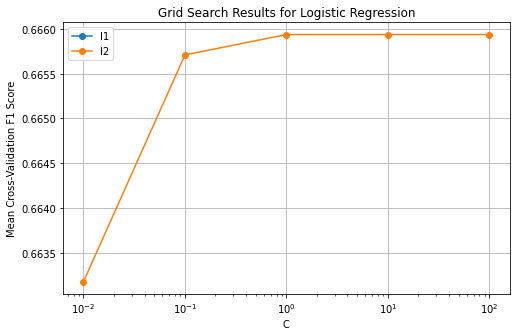

In [15]:
#Visualize parmeters
import matplotlib.pyplot as plt
results = pd.DataFrame(grid_search.cv_results_)

plt.figure(figsize=(8,5))

for penalty in ["l1", "l2"]:
    subset = results[results["param_penalty"] == penalty]

    plt.plot(
        subset["param_C"].astype(float),
        subset["mean_test_score"],
        marker="o",
        label=penalty
    )

plt.xscale("log")
plt.xlabel("C")
plt.ylabel("Mean Cross-Validation F1 Score")
plt.title("Grid Search Results for Logistic Regression")
plt.legend()
plt.grid(True)

plt.show()

In [16]:
# Train, test and evaluate a final version of your model using the optimal hyperparameter values.
final_model = LogisticRegression(C=1, penalty='l2')
final_model.fit(X_train_s, y_train)#Train

final_pred = final_model.predict(X_test_s)#Test

final_accuracy = accuracy_score(y_test, final_pred)#eval

final_f1 = f1_score(y_test, final_pred,average="binary")

print("Final accuracy:", final_accuracy)
print("Final F1 score:", final_f1)

Final accuracy: 0.844311377245509
Final F1 score: 0.6339350180505415


                                 Feature  Coefficient
0                                    age     0.312799
1                          education-num     0.781597
2                           capital-gain     0.847107
3                           capital-loss     0.257902
4                         hours-per-week     0.396349
5                  workclass_Federal-gov     0.106904
6                    workclass_Local-gov    -0.020420
7                 workclass_Never-worked    -0.080872
8                      workclass_Private     0.024150
9                 workclass_Self-emp-inc     0.057414
10            workclass_Self-emp-not-inc    -0.093872
11                   workclass_State-gov    -0.024876
12                 workclass_Without-pay    -0.132644
13               marital-status_Divorced    -0.212037
14      marital-status_Married-AF-spouse     0.051986
15     marital-status_Married-civ-spouse     0.724362
16  marital-status_Married-spouse-absent    -0.072358
17          marital-status_N

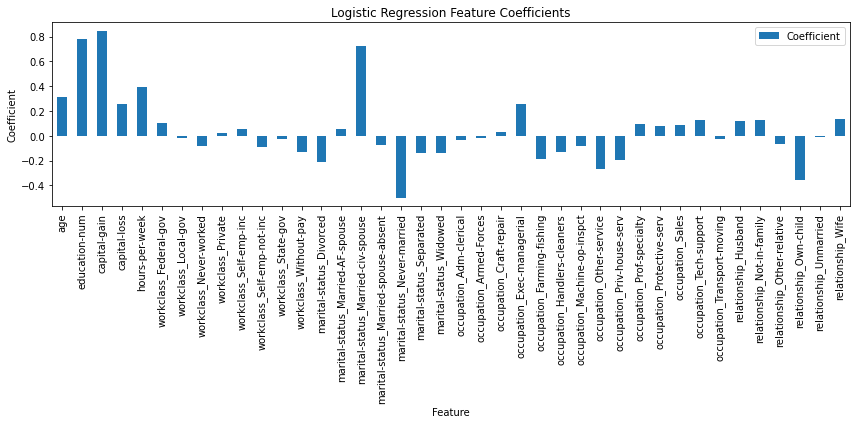

In [17]:
# Interpret your model's outputs 
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": final_model.coef_[0]
})

print(coefficients)

coefficients.plot(
    x="Feature",
    y="Coefficient",
    kind="bar",
    figsize=(12,6)
)

plt.title("Logistic Regression Feature Coefficients")
plt.ylabel("Coefficient")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

### Model Reflection:

<b>Task</b>: In the markdown cell below, answer the following questions:

1. Which model did you choose and why? Reference your problem and data characteristics in your explanation.
2. What did you learn through the model selection process?
3. How do you interpret your model's outputs? What do the predictions or coefficients or feature importances actually mean in the context of your problem?
4. Are there any fairness or ethical concerns with your model? Who might be harmed by incorrect predictions, and are any groups more likely to be affected?

1. For the Census Income Data problem I chose the Logisitic Regression Model. My data had features of type object, ints and float requiring one hot encoding. So I used the LogisticsRegression model because the dataset contained many numerical and encoded categorical features. The model is also well suited for binary clasification problems as it can generalize it's decsions bouandry well, and out peform decsions trees and KNN models, doing well with numbers and complex numerical relationships where a clear pattern doesn't always exist. KNN models need to see a clear pattern between examples with simllar features and with income, people with very simllar features can have a completley diffrent income because of 1 or 2 points, and Decsions Trees are too rigid in it's decsions making and would overfit Census data, leaving me with Logistic Regression as my choice.

2. I learned that very small things can change which model is best suited for a machine learning problem and tehre really is no one model fits all. Each problem is unqiue, At first I believed KNN would be the best fit because similar features often have similar labels, but I realized income can change significantly even when people have nearly identical features. I also learned that hyperparameter tuning does not always improve a model. In my case, grid search found that the default logistic regression parameters already performed the best, showing me no diffrnece in accuracy or my f1 score.

3. The coefficients show how much a feature influences the model's prediction of whether someone earns more than 50,000 per year. Positive coefficients increase the probability that the model predicts an income greater than 50K, and negative coefficients decrease that chance. For example, capital gain, years of education, being married, working more hours per week, and age all had positive coefficients, so they increased the likelihood of predicting a higher income. On the other hand, being never married, having the relationship status of own-child, or working in occupations such as other service had negative coefficients, making the model less likely to predict an income above 50K. Larger coefficients(negative or positive) mean a stronger influence on the prediction.

4. One ethical concern is that the model learns patterns from historical census data, which may contain existing social or economic biases. I tried to solve this issue by removing features I thought could create bias in the model and unintentionally reinforce those biases when making predictions. Incorrect predictions would affect individuals if the model were used for decisions like loans or financial assistance. It is important to evaluate the model for fairness across different groups before using it in real world decisions. With more knowlegde I would test the model with those features dropped and included to get a clear compaisron of the affects 

---
## ✔️ Unit 5 Checkpoint

**Stop here.** If you have completed Parts 1 through 5, you are done with the Unit 5 portion of this capstone.

Parts 6 and 7 require you to train and evaluate a neural network. You will learn about neural networks in the Unit 6 asynchronous content. Do not start Part 6 until you have completed that material and your lab facilitator has directed you to continue. Do not submit your work for grading until you complete Parts 6 and 7.

Make sure your notebook is saved before you close it.

---
## Part 6: Train, Test, Evaluate and Improve a Neural Network

> **⚠️ Before you write any code in Part 6, do this first.**
> 
> Your notebook does not retain variables between sessions. All of your variables and everything else need to be restored to memory before any code below will work.
> 
> Go to **Kernel > Restart & Run All** to re-run Parts 1 through 5, then scroll back here to continue. If you skip this step, you will see a `NameError` on the first code cell below.

Now you will apply a neural network to the same problem and dataset. You will use Keras to build a feedforward neural network for binary classification.

The scaffolding below will walk you through the steps. Where you see a **Task**, fill in the code. Where you see a **Decision**, you are making an independent choice about your architecture or training process. For each decision, add a comment explaining what you chose and why.


### Prepare Your Data for the Neural Network

Neural networks require all input features to be numeric and scaled. If your features are on very different scales (for example, one feature ranges from 0 to 90 and another from 0 to 99999), the model may train less effectively and have difficulty learning meaningful patterns from the data.

Before training your network, create scaled versions of your training and test data. Use `StandardScaler()` from `sklearn.preprocessing` to standardize your features: 

<b>Task</b>: Complete the code cell below to fit the scaler on your training data, then transform both training and test sets. Save the results to new variables (for example, `X_train_scaled` and `X_test_scaled`) so your original data remains available for reference.

**Note:** Use your scaled data for all neural network steps below.

In [18]:
# Scale your data for the neural network

# Create the scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler to transform the test data
X_test_scaled = scaler.transform(X_test)

### Step 1: Define Your Model Architecture

You will use the Keras `Sequential` class to build your network. Your network should have:

- An input layer with the correct shape for your data
- At least two hidden layers using the `Dense` class
- An output layer appropriate for binary classification

<b>Task:</b> Create a `Sequential` model object and name it `nn_model`. Then construct and add each layer.

**Decision:** How many hidden layers will you use? How many units in each? What activation function will you use for the hidden layers? Add a comment explaining your choices.

In [19]:
# Get the number of features in your training data
n_features = X_train_scaled.shape[1]

# Create the neural network model
nn_model = keras.Sequential()

# Create the input layer and add the input layer to the 'nn_model' object
input_layer = keras.layers.InputLayer(input_shape= n_features)
nn_model.add(input_layer)

# Create the hidden layers and add the hidden layers to the 'nn_model' object
# Decision: How many layers? How many units? What activation function?
# Add a comment explaining your choices.
hid_layer1 = keras.layers.Dense(units=64, activation='relu')
hid_layer2 = keras.layers.Dense(units=32, activation='relu')
hid_layer3 = keras.layers.Dense(units=16, activation='relu')

nn_model.add(hid_layer1)
nn_model.add(hid_layer2)
nn_model.add(hid_layer3)

#Three hidden layers (64, 32, 16) allow the model to learn increasingly
# complex patterns while gradually reducing the information to the most
# important features before making the final prediction. But not to many that it overfits

# Create the output layer and add the output layer to the 'nn_model' object
# Use the correct number of units and activation function for binary classification
output_layer = keras.layers.Dense(units=1, activation='sigmoid')
nn_model.add(output_layer)

# Print a summary of your model
nn_model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 64)                2624      
_________________________________________________________________
dense_1 (Dense)              (None, 32)                2080      
_________________________________________________________________
dense_2 (Dense)              (None, 16)                528       
_________________________________________________________________
dense_3 (Dense)              (None, 1)                 17        
Total params: 5,249
Trainable params: 5,249
Non-trainable params: 0
_________________________________________________________________


### Step 2:  Define the Optimization Function

<b>Task:</b> In the code cell below, create an optimizer object. Use stochastic gradient descent (SGD) with a learning rate of your choosing.

**Decision:** What learning rate will you use? Add a comment explaining your choice.

In [20]:
# Decision: What learning rate will you use? Add a comment explaining your decision.
# A learning rate of 0.1 has a good balance between fast learning
# and stable convergence when using SGD.

sgd_optimizer =  keras.optimizers.SGD(learning_rate=0.1)

### Step 3: Define the Loss Function

<b>Task:</b> In the code cell below, create a binary cross entropy loss function using `keras.losses.BinaryCrossentropy()`. Use  the parameter `from_logits=False`. 

In [21]:
loss_fn = keras.losses.BinaryCrossentropy(from_logits=False)

### Step 4: Compile the Model

<b>Task:</b> In the code cell below, package the network architecture with the optimizer and the loss function using the `compile()` method. Use the `accuracy` evaluation metric.

In [22]:
nn_model.compile(optimizer=sgd_optimizer, loss=loss_fn, metrics=['accuracy'])

### Step 5: Fit the Model to the Training Data

We will define our own callback class to output information from our model while it is training. Make sure you execute the code cell below so that it can be used in subsequent cells.

In [23]:
class ProgBarLoggerNEpochs(keras.callbacks.Callback):
    
    def __init__(self, num_epochs: int, every_n: int = 50):
        self.num_epochs = num_epochs
        self.every_n = every_n
    
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n == 0:
            s = 'Epoch [{}/ {}]'.format(epoch + 1, self.num_epochs)
            logs_s = ['{}: {:.4f}'.format(k.capitalize(), v)
                      for k, v in logs.items()]
            s_list = [s] + logs_s
            print(', '.join(s_list))


<b>Task:</b> Use the `fit()` method to fit your model to the training data. Save the result to variable `history.`

Use the `validation_split` parameter to reserve a portion of your training data for validation during training (a common choice is `validation_split=0.2`). After each epoch, the model is evaluated on this validation data, allowing you to monitor how well the model generalizes and helping you detect overfitting.

Also, use the the logger class defined above to track training progress.

**Decision:** How many epochs will you train for? Add a comment explaining your choice.

**Note:** This may take a while to run.

In [24]:
# Decision: How many epochs? Add a comment.
# I chose 15 epochs, first I tested with a large number like 150 to see how my model adapted
#But after 15 I notice validation loss increasing but accuracy increasing meaning model was 
#overfitting with more epochs. 15 is a good middle ground to train model and generalize well
t0 = time.time() # start time

num_epochs = 15

history = nn_model.fit(X_train_scaled, y_train, epochs=num_epochs, validation_split=0.2, 
                       verbose=0,
                       callbacks=[ProgBarLoggerNEpochs(num_epochs, every_n=5)]
                      )


t1 = time.time() # stop time

print('Elapsed time: %.2fs' % (t1-t0))

Epoch [5/ 15], Loss: 0.3013, Accuracy: 0.8594, Val_loss: 0.3140, Val_accuracy: 0.8549
Epoch [10/ 15], Loss: 0.2921, Accuracy: 0.8655, Val_loss: 0.3152, Val_accuracy: 0.8547
Epoch [15/ 15], Loss: 0.2878, Accuracy: 0.8656, Val_loss: 0.3289, Val_accuracy: 0.8457
Elapsed time: 14.33s


### Step 6: Visualize Training Performance

<b>Task:</b>  

Create two plots to visualize the model's performance over time:
1. Training loss and validation loss over epochs, on the same axes.
2. Training accuracy and validation accuracy over epochs, on the same axes.

Label your axes and include a legend.

Use the `history` object returned by `fit()` to obtain this information. 



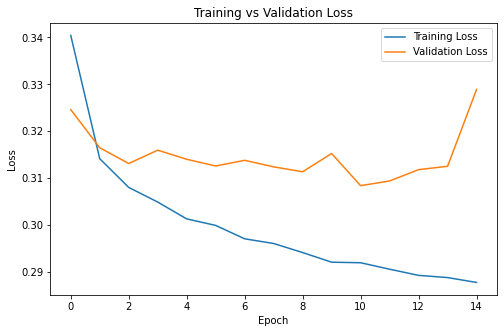

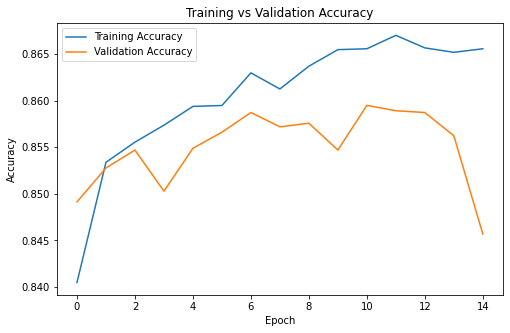

In [25]:
# Plot training loss and validation loss over epochs
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

# Plot training accuracy and validation accuracy over epochs
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

### Step 7: Evaluate the Model's Performance on the Test Set

<b>Task:</b> Use your neural network to generate predictions on the test set and evaluate its performance using accuracy and F1 score. Use `nn_model.predict()` to generate predictions. Since `nn_model.predict()` returns probabilities, apply a threshold of 0.5 to convert probabilities into binary class predictions before computing your metrics. Save your accuracy and F1 score results to clearly named variables so you can compare them to the results from your previous model. Print the results.

In [30]:
# Generate predictions from your neural network using your scaled test data
# nn_model.predict() returns probabilities — apply a threshold of 0.5 to get class labels

pred_prob= nn_model.predict(X_test_scaled)

y_nn_pred = (pred_prob >= 0.5).astype(int)

In [31]:
# Compute accuracy and F1 score for the neural network and print the results

nn_accuracy = accuracy_score(y_test, y_nn_pred)
nn_f1_score = f1_score(y_test, y_nn_pred)

print("Neural Network Accuracy:", nn_accuracy)
print("Neural Network F1 Score:", nn_f1_score)

Neural Network Accuracy: 0.8444649163212038
Neural Network F1 Score: 0.6756324047390331


#### Neural Network Reflection:

<b>Task:</b> In the markdown cell below, answer the following questions:

1. Walk through the architecture decisions you made: number of layers, number of units, activation functions, learning rate, and number of epochs. Why did you make each of those choices?
2. What did your training curves tell you? Did you see any signs of overfitting or underfitting?
3. How did your neural network perform on the test set? Report your accuracy and F1 score here and note whether the result surprised you given what your training curves showed.

1. I built a neural network with three hidden layers containing 64, 32, and 16 units. I used a gradually decreasing number of units so that the model could first learn a broad patterns and then reduce those patterns to the most important information before making a prediction. I used the ReLU activation function in each hidden layer because it allows the network to learn nonlinear relationships without skweing results for negative outcomes. The output layer contained one unit with a sigmoid function because this was a binary classification problem and the model needed a probability between 0 and 1.

2. I trained the model using stochastic gradient descent with a learning rate of 0.1. I selected this learning rate because it allows the model to update its weights steadily without making changes to large. I trained the model for 15 epochs. This gave the model enough time to improve while limiting unnecessary training and the risk of overfitting.

3. The training curves showed that the training loss decreased and training accuracy increased over time. The validation performance improved more slowly and remained below the training performance. There was hithces in the data and it wasn't exactly a smooth curve, I believe this suggests that the model was starting to overfit slightly, and more epochs would have worsend this. Although with only 15 iterations the gap was not extremely large. I did not see strong signs of underfitting because the model achieved pretty high training and validation accuracy.

4. On the test set, the neural network achieved an accuracy of 0.8445, and an F1 score of 0.6756. The accuracy shows that the model correctly classified most test examples. However, the lower F1 score means that it was less effective at correctly identifying the positive income class. The result was not very surprising because the validation accuracy during training was also around 85%, so the test performance was consistent.

## Part 7: Compare Your Models and Reflect

You have now applied two different approaches to the same problem. In this final section, you will put those results side by side and reflect on what you learned.

###  Results Summary

<b>Task:</b> In the code cell below, create a summary table using a Pandas DataFrame that displays each evaluation metric for both models side by side. Use the variables you created for the accuracy and F1 score metrics. The table should make it easy to compare performance at a glance across every metric you computed.

In [33]:
# Build a side-by-side comparison of your two models using the metric variables
# you created. For example:
#
results = pd.DataFrame({'Metric': ['Accuracy', 'F1 Score'],
    'LogisticRegression': [final_accuracy, final_f1],
    'Neural Network': [nn_accuracy, nn_f1_score]
 })
print(results.to_string(index=False))


   Metric  LogisticRegression  Neural Network
 Accuracy            0.844311        0.844465
 F1 Score            0.633935        0.675632


### Comparative Analysis

<b>Task:</b> In the markdown cell below, write a comparative analysis that addresses the following. 

1. **Performance comparison.** How did the two models perform relative to each other? Which metrics improved, which stayed the same, and which got worse?

2. **Was the added complexity worth it?** Neural networks are more complex to build, tune, and interpret. Given the performance difference you observed, do you think the neural network justified that added complexity for this problem?

3. **Recommendation.** If you were presenting this work to your company and their client as described in the business brief, which model would you recommend deploying and why? Consider not just performance but also interpretability, training time, and what the costs of different types of errors look like for that specific client.

4. **What you would do next.** If you had more time, what would you try to improve your results? This could include trying different architectures, additional preprocessing steps, different features, or techniques to address class imbalance. Be specific.

1. The two models were neraly idnetical when it comes to accuracy(84.43 vs 84.44), and the f1 scores were simllar as well, although the Nueral Network outpeformed our Logistic Regression Model by about 4 percent. Meaning they predicted the results at the almost the same rate but our Neural Network was better at finding postive results while balancing precision and Recall. 

2. Honestly in this case I would say, the added complexity of the neural network was not worth it. This of course come down to the way I trained the NN, but there was little to no differnece in my accuracy scores. Now it did give 4 percent better f1 scores but without a diffrence in accuracy this small 4 percent bump is not enough of a highlight. That along with the fact that training the Neural Network was a much more iterative and hands on process I would say it's not worth it.

3. If I had to recommend one of these two models I would confidntently go with the Logistic Regression model. Logistic Regression in compairson with Neural Networks are far easier to train and less costly. In addition to the identical to better model peformance(when considering effiency, training time, and metrics) I could also represent this model to clients or stakeholders much easier. Because logistic regression produces a clear decision boundary and feature coefficients, it is much easier to visualize and communicate how the model makes its decisions.

4. If I had more time I would hone in on only the Logistic Regression Model and run more test with diffrent sets of features. I dropped multiple features to avoid model bias, but I would like to see the difference in model peformance with these features included. I would also tune the hyperparmeters more, by getting more specfic and itertating through many more options using GridsearchCv cross-validation to make sure model generalizes very well.

---
## AI Use Attestation

Reflect honestly on how you used AI tools during this capstone. You are expected to have used AI somewhere in your workflow, and your reflection on that use is what will be evaluated: How clearly you describe your choices, how you verified your work, and what you learned from the process. If you chose not to use AI, explain why. Answer each question in the markdown cell below.

1. Where and at what stages of this capstone did you use AI tools, for example, Claude during brainstorming, coding, or debugging? If you chose not to use AI, explain why.
2. Identify one part of the capstone that required the most effort or thought. What made it challenging, and how did you work through it, with AI or without AI? If you used AI at this point, feel free to share a prompt that worked well or one that did not land the way you expected.
3. How did you verify that your work was correct? What did you look for to catch a mistake, whether it came from AI output or your own reasoning?
4. What is one thing you would do differently next time, either in how you approached the capstone or in how you used AI during it?

1. I used Ai tools throughout the process of this capstone project from the problem understanding to the final evaluation. I mainly used Chatgpt for this project, helping me to better understand the census problem, and how I should think about how my current steps whether that be prepping data or selecting a specfic model would affect my metrics.


2. The section that required the most effort and where I used AI most was the Data preperation/cleaning phase of the ML lifecycle. I wanted to think carefully about my feature selection, and how removing specfic feature could boost effiency and model peformance. A specfic prompt I used in AI was to help me graph boxplots to visualize how each featured correlated with the desired label. Based on this I was able to remove features that had no correlation with the models prediction, while also reducing bias by removing features that could negativley impact the models learning bias. I bounced my ideas off of gpt consistently in this phase to ensure I didn't undefit or overfit my model by removing to many features or keeping to many irrelevant ones


3. To verify correctness I relied on creatings plots and graphs to show me how a models accuracy changed when using different parameters. I hadn't memorized much of the code nescaryy to create graphs using matplot or seaborn, but I knew the type of figures I needed, so I used AI heavily in this phase to generate the code needed so I could verify if my model was producing good results. By comparing numbers with different inputs and looking at plots I was able to verify that my work was correct


4. In how I approached the capstone, I would spend more time planning my workflow before beginning the project. Rather than experimenting with different models and hyperparameters as I went, in the future I would create a clear plan for what I wanted to test and how I would evaluate each change.